In [88]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyGDM2 import  (structures, materials, core, 
                    linear, fields, propagators, 
                    tools)
                

In [89]:
def get_spectrum(geometry, step):
    """ Obtain a simulated absorption spectra for a hexagonal nanorod mesh
    L -- length of the cylinder
    R -- radius of the cylinder
    """
    #geometry = structures.sphere(step, R=r, mesh='hex')
    material = materials.gold()
    struct = structures.struct(step, geometry, material, verbose=False)
    struct = structures.center_struct(struct)
    field_generator = fields.plane_wave
    wavelengths = np.linspace(400, 800, 81)
    kwargs = dict(theta=0, inc_angle=180)

    efield = fields.efield(field_generator,
                   wavelengths=wavelengths, kwargs=kwargs)
    
    dyads = propagators.DyadsQuasistatic123(n1 = 1.33, n2 = 1.33, n3 = 1.33)

    sim = core.simulation(struct, efield, dyads)
    sim.scatter(verbose=False)
    field_kwargs = tools.get_possible_field_params_spectra(sim)

    config_idx = 0
    wl, spectrum = tools.calculate_spectrum(sim,
                        field_kwargs[config_idx], linear.extinct)
    
    abs_ = spectrum.T[2]/np.max(spectrum.T[2])
    return abs_, geometry

## Specify the Step Size and Radius

The simulator simulates the spectra of 7 equally spaced apart spheres with a gaussian distributed radius of mean "radius_mean" and standard deviation "radius_std". 

In [376]:
step = 3

In [413]:
np.random.seed(5)
n_spheres = 7
radius_list = []
for i in range(n_spheres):
    # Normal distribution parameters for Sphere Radius 
    radius_mean = 6
    radius_std = 3
    r = (np.random.randn(1)[0]*radius_std + radius_mean)/step
    radius_list.append(r)
    geometry = structures.sphere(step, R=r, mesh='cube')
    loc_array = np.array([[0,0,0],[0,0,1],[0,0,-1],[1,0,0],[-1,0,0],[0,1,0],[0,-1,0]])
    sphere = np.hstack((geometry[:,0].reshape(-1,1) + 20*loc_array[i,0]*radius_mean, geometry[:,1].reshape(-1,1) + 20*loc_array[i,1]*radius_mean, geometry[:,2].reshape(-1,1)+ 20*loc_array[i,2]*radius_mean))
    if i == 0:
        sample = sphere
    else:
        sample = np.vstack((sample, sphere))

## Plot the Cluster Geometry

Text(0.5, 0, 'z')

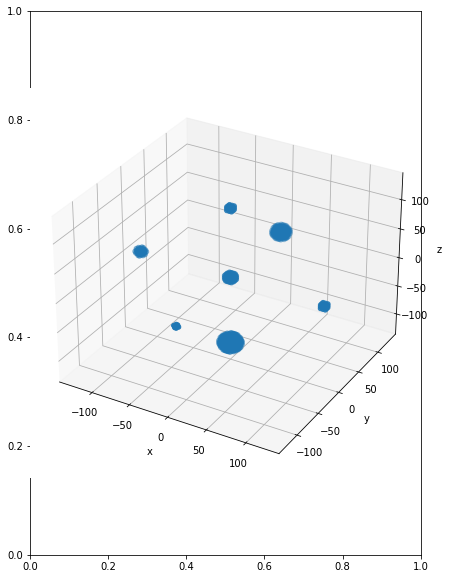

In [414]:
#geometry = structures.sphere(step, R=5, mesh='cube')
fig, ax = plt.subplots(figsize= (7,10))
ax = plt.axes(projection='3d')
geometry = sample
# Data for three-dimensional scattered points
xdata = geometry[:,0]
ydata = geometry[:,1]
zdata = geometry[:,2]
ax.scatter3D(xdata, ydata, zdata, cmap='Greens');
#ax.set_xlim([0, 120])
#ax.set_ylim([0, 120])
#ax.set_zlim([0, 120])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
#ax.view_init(elev=30, azim=90)

## Run the Simulation 

In [415]:
I, g = get_spectrum(geometry, step)

In [416]:
wavelength = np.linspace(400,800,81)

Text(0, 0.5, 'Intensity')

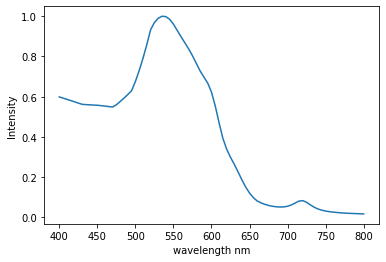

In [408]:
#Rad 6, poly 1
plt.plot(wavelength, I)
plt.xlabel('wavelength nm')
plt.ylabel('Intensity')

Text(0, 0.5, 'Intensity')

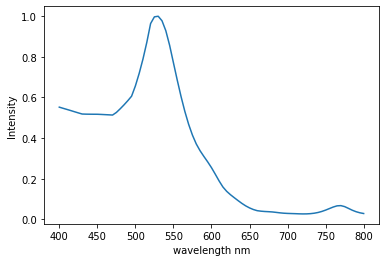

In [418]:
#Radius of 6, Polydispersity of 3
plt.plot(wavelength, I)
plt.xlabel('wavelength nm')
plt.ylabel('Intensity')

In [409]:
array = np.hstack((wavelength.reshape(-1,1), I.reshape(-1,1)))

In [410]:
array

array([[4.00000000e+02, 5.99072368e-01],
       [4.05000000e+02, 5.93027571e-01],
       [4.10000000e+02, 5.87133420e-01],
       [4.15000000e+02, 5.81078123e-01],
       [4.20000000e+02, 5.74689892e-01],
       [4.25000000e+02, 5.68454231e-01],
       [4.30000000e+02, 5.62365755e-01],
       [4.35000000e+02, 5.60876477e-01],
       [4.40000000e+02, 5.59733182e-01],
       [4.45000000e+02, 5.58672298e-01],
       [4.50000000e+02, 5.57690042e-01],
       [4.55000000e+02, 5.55651811e-01],
       [4.60000000e+02, 5.53447773e-01],
       [4.65000000e+02, 5.51223992e-01],
       [4.70000000e+02, 5.48973508e-01],
       [4.75000000e+02, 5.60084767e-01],
       [4.80000000e+02, 5.76067342e-01],
       [4.85000000e+02, 5.92974868e-01],
       [4.90000000e+02, 6.10884010e-01],
       [4.95000000e+02, 6.29880696e-01],
       [5.00000000e+02, 6.75588935e-01],
       [5.05000000e+02, 7.30357984e-01],
       [5.10000000e+02, 7.91123836e-01],
       [5.15000000e+02, 8.58515220e-01],
       [5.200000

In [419]:
df = pd.DataFrame(array, columns=['Wavelength', 'Intensity'])

In [420]:
df.to_csv('rad_6_poly_3.csv')